In [1]:
# ///////////////////////////////////////////////
#  definir en las tablas las variables
from numpy import *
import pandas as pd
import matplotlib.pyplot as plt

import datetime

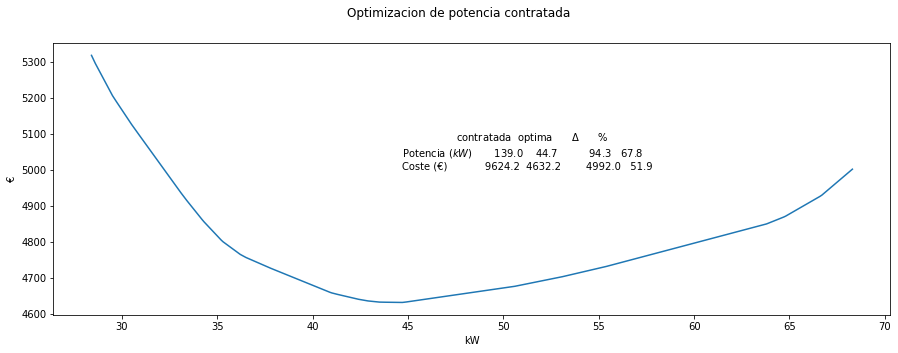

In [62]:

df=pd.DataFrame()
df_modulo=pd.read_csv("datos/efe1-m1.csv", index_col=0, header=0)
df["p1"]=df_modulo.kw
df_modulo=pd.read_csv("datos/efe1-m2.csv", index_col=0, header=0)
df["p2"]=df_modulo.kw
df_modulo=pd.read_csv("datos/efe1-m3.csv", index_col=0, header=0)
df["p3"]=df_modulo.kw
df_modulo=pd.read_csv("datos/efe1-m4.csv", index_col=0, header=0)
df["p4"]=df_modulo.kw
df_modulo=pd.read_csv("datos/efe1-m5.csv", index_col=0, header=0)
df["p5"]=df_modulo.kw
df_modulo=pd.read_csv("datos/efe1-m6.csv", index_col=0, header=0)
df["p6"]=df_modulo.kw


# 

aa=df.describe()
# aa
pc=139 #kW


# para buscar el punto en cuyo contorno debe estar el minimo parto de la mdeia de los valores
p=['p1','p2','p3']
pcm=int(aa.loc['mean',p].mean()*10)
# pcm



# df=pd.read_csv("datos/maximetro.csv", header=[0])
df['diasmes']=[31,28,31,30,31,30,31,31,30,31,30,31]
# medida Pi
df['P1']=df[["p1", "p4"]].max(axis=1)
df['P2']=df[["p2", "p5"]].max(axis=1)
df['P3']=df[["p3", "p6"]].max(axis=1)
# a facturar
def coste(pc):
    pp='P1'
    df["f1"]=where(df[pp] <  0.85*pc,0.85*pc,
                    where((df[pp] >= 0.85*pc) & (df[pp] <= 1.05*pc),df[pp],
                          where(df[pp] >  1.05*pc,df[pp]+2*(df[pp]-1.05*pc),0)))
    pp='P2'
    df["f2"]=where(df[pp] <  0.85*pc,0.85*pc,
                    where((df[pp] >= 0.85*pc) & (df[pp] <= 1.05*pc),df[pp],
                          where(df[pp] >  1.05*pc,df[pp]+2*(df[pp]-1.05*pc),0)))
    pp='P3'
    df["f3"]=where(df[pp] <  0.85*pc,0.85*pc,
                    where((df[pp] >= 0.85*pc) & (df[pp] <= 1.05*pc),df[pp],
                          where(df[pp] >  1.05*pc,df[pp]+2*(df[pp]-1.05*pc),0)))
    s1=0.111585986 # €/kW dia 
    s2=0.066951589 # €/kW dia 
    s3=0.044634397 # €/kW dia
    df["S1"]=df["f1"]*s1*df['diasmes']
    df["S2"]=df["f2"]*s2*df['diasmes']
    df["S3"]=df["f3"]*s3*df['diasmes']
    S=df.sum().S1+df.sum().S2+df.sum().S3
    return S



# para encontrar el optmo
# /////////////////////////////////////////////////////
# df[['pm1','pf1']]
SS=[]
xx=[]
# pc=pc*100 #kW
for x in range(pcm-100, pcm+300):
    poo=x/10 #kW
    S=coste(poo)
    SS.append(S)
    xx.append(x/10)
# ////////////////////////////////////////////////////
#     
dx=pd.DataFrame()
dx["Potencia_contratada"]=xx
dx["Coste_anual"]=SS

Smin = dx['Coste_anual'].min()
indice = dx['Coste_anual'].idxmin()
po=dx.loc[indice,"Potencia_contratada"]
# resultados

Spc=coste(pc)
Spo=coste(po)

ii=['Potencia ($kW$)','Coste (€)']
cc = ["contratada",'optima']
qq=pd.DataFrame(columns=cc,index=ii)    
qq['contratada']=[pc,round(Spc,1)]
qq['optima']=[po,round(Spo,1)]
qq['    $\Delta$']=qq.contratada-qq.optima
qq['    %']=round((qq.contratada-qq.optima)/qq.contratada*100,1)

qq

# pra representar la funcion de coste
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = plt.plot(xx,SS)
ax = plt.suptitle('Optimizacion de potencia contratada')
ax = plt.ylabel("€")
ax = plt.xlabel("kW")
# html = qq.to_markdown()
ax=plt.text(po, Spo*1.08, str(qq))



In [ ]:
%%html
<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value=" 
Curso:  Auditorías energéticas
Alumno: Francisco Manuel Roman Gamez

"></form>